In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df_tether = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\tether.csv') 
df_bitcoin = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\bitcoin.csv') 
df_ethereum = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\ethereum.csv') 
df_usd_coin = pd.read_csv(r'D:\USDT\csv\stable_coin_csv\usd coin.csv') 

In [3]:
df_tether.head() 

,Date,Open,High,Low,Close,Volume,Currency
0,2017-04-14,0.9939,0.9960,0.9689,0.9899,71652,USD
1,2017-04-15,0.9899,0.9899,0.9676,0.9896,14922,USD
2,2017-04-16,0.9896,0.9896,0.9515,0.9515,12412,USD
3,2017-04-17,0.9515,0.9698,0.9211,0.9392,38750,USD
4,2017-04-18,0.9392,0.9628,0.9207,0.9450,39253,USD


In [4]:
# ==================== 数据筛选 ====================
def filter_date_range(df, start_date='2021-04-20', end_date='2021-06-15'):
    """筛选指定日期范围的数据"""
    df['Date'] = pd.to_datetime(df['Date'])
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    return df.loc[mask].copy() 

# 筛选数据
df_tether_filtered = filter_date_range(df_tether)
df_bitcoin_filtered = filter_date_range(df_bitcoin)
df_ethereum_filtered = filter_date_range(df_ethereum) 
df_usd_coin_filtered = filter_date_range(df_usd_coin) 

In [5]:
df_tether_filtered.info() 

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 1466 to 1522
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      57 non-null     datetime64[us]
 1   Open      57 non-null     float64       
 2   High      57 non-null     float64       
 3   Low       57 non-null     float64       
 4   Close     57 non-null     float64       
 5   Volume    57 non-null     int64         
 6   Currency  57 non-null     str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 3.2 KB


In [6]:
# ==================== 数据清洗 ====================
def clean_crypto_data(df, coin_name):
    """清洗加密货币数据"""
    df = df.copy()
    
    # 1. 转换日期格式
    df['Date'] = pd.to_datetime(df['Date'])
    
    # 2. 按日期排序
    df = df.sort_values('Date').reset_index(drop=True)
    
    # 3. 检查缺失值
    print(f"\n{coin_name} 缺失值统计:")
    print(df.isnull().sum())
    
    # 4. 处理缺失值（前向填充）
    df = df.ffill()
    
    # 5. 检查异常值
    numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for col in numeric_cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR
            upper_bound = Q3 + 3 * IQR
            
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            if len(outliers) > 0:
                print(f"\n{coin_name} {col} 发现 {len(outliers)} 个异常值")
                print(outliers[['Date', col]])
    
    # 6. 重命名列（添加币种前缀）
    rename_dict = {
        'Open': f'{coin_name}_Open',
        'High': f'{coin_name}_High',
        'Low': f'{coin_name}_Low',
        'Close': f'{coin_name}_Close',
        'Volume': f'{coin_name}_Volume'
    }
    df = df.rename(columns=rename_dict)
    
    return df

# 清洗所有数据
df_tether_clean = clean_crypto_data(df_tether_filtered, 'USDT')
df_bitcoin_clean = clean_crypto_data(df_bitcoin_filtered, 'BTC')
df_ethereum_clean = clean_crypto_data(df_ethereum_filtered, 'ETH')
df_usd_coin_clean = clean_crypto_data(df_usd_coin_filtered, 'USDC') 



USDT 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDT Volume 发现 1 个异常值
         Date      Volume
29 2021-05-19  1073871488

BTC 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

BTC Volume 发现 1 个异常值
         Date  Volume
29 2021-05-19  607096

ETH 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDC 缺失值统计:
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64

USDC High 发现 3 个异常值
         Date    High
26 2021-05-16  1.0023
27 2021-05-17  1.0024
29 2021-05-19  1.0049

USDC Low 发现 2 个异常值
        Date     Low
0 2021-04-20  0.9847
1 2021-04-21  0.9950

USDC Volume 发现 1 个异常值
         Date     Volume
29 2021-05-19  829656448


In [7]:
# ==================== 合并数据 ====================
# 以 USDT 为基准，合并其他数据
master_df = df_tether_clean[['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 'USDT_Volume']].copy()

# 合并 BTC 数据
master_df = pd.merge(master_df, 
                     df_bitcoin_clean[['Date', 'BTC_Close', 'BTC_Volume']], 
                     on='Date', how='left')

# 合并 ETH 数据
master_df = pd.merge(master_df, 
                     df_ethereum_clean[['Date', 'ETH_Close', 'ETH_Volume']], 
                     on='Date', how='left')

# 合并 USDC 数据
master_df = pd.merge(master_df, 
                     df_usd_coin_clean[['Date', 'USDC_Close', 'USDC_Volume']], 
                     on='Date', how='left')

print(f"\n合并后数据形状: {master_df.shape}")
print(f"合并后数据预览:")
print(master_df.head())

# 检查合并后的缺失值
print(f"\n合并后缺失值:")
print(master_df.isnull().sum()) 



合并后数据形状: (57, 12)
合并后数据预览:
        Date  USDT_Open  USDT_High  USDT_Low  USDT_Close  USDT_Volume  \
0 2021-04-20     1.0007     1.0019    1.0000      1.0008    390712736   
1 2021-04-21     1.0004     1.0007    0.9999      1.0002    266370048   
2 2021-04-22     1.0002     1.0010    0.9995      1.0004    386373984   
3 2021-04-23     1.0004     1.0016    0.9998      1.0008    507062112   
4 2021-04-24     1.0006     1.0024    1.0005      1.0018    150261312   

   BTC_Close  BTC_Volume  ETH_Close  ETH_Volume  USDC_Close  USDC_Volume  
0    56483.2      115485    2332.14     1858410      0.9989    231269264  
1    53820.2      100263    2360.81     2104047      0.9995    194637008  
2    51729.5      168125    2401.10     3165540      0.9998    240331904  
3    51143.6      214455    2367.31     3456897      0.9991    364535552  
4    50088.9       82250    2215.93     1614413      0.9988    109961768  

合并后缺失值:
Date           0
USDT_Open      0
USDT_High      0
USDT_Low       0
USDT_C

In [8]:
# ==================== 特征工程 ====================

def create_features(df):
    """创建所有特征"""
    df = df.copy()
    
    # ========== 1. 目标变量：USDT 脱锚程度 ==========
    df['USDT_Deviation'] = abs(df['USDT_Close'] - 1.00)  # 绝对偏离
    df['USDT_Deviation_Pct'] = (df['USDT_Close'] - 1.00) * 100  # 百分比偏离
    df['USDT_Premium'] = df['USDT_Close'] - 1.00  # 溢价/折价
    
    # ========== 2. 价格相关特征 ==========
    # USDT 价格特征
    df['USDT_Range'] = df['USDT_High'] - df['USDT_Low']  # 日内波动范围
    df['USDT_HL_Ratio'] = df['USDT_High'] / df['USDT_Low']  # 高低比
    df['USDT_OC_Change'] = df['USDT_Close'] - df['USDT_Open']  # 开收盘变化
    
    # USDC 对比特征（对照组）
    df['USDC_Deviation'] = abs(df['USDC_Close'] - 1.00)
    df['USDT_USDC_Spread'] = df['USDT_Close'] - df['USDC_Close']  # 价差
    
    # ========== 3. 收益率特征 ==========
    # USDT 收益率
    df['USDT_Return'] = df['USDT_Close'].pct_change()
    df['USDT_Return_3d'] = df['USDT_Close'].pct_change(3)  # 3日收益率
    df['USDT_Return_7d'] = df['USDT_Close'].pct_change(7)  # 7日收益率
    
    # BTC 收益率（市场环境）
    df['BTC_Return'] = df['BTC_Close'].pct_change()
    df['BTC_Return_3d'] = df['BTC_Close'].pct_change(3)
    df['BTC_Return_7d'] = df['BTC_Close'].pct_change(7)
    
    # ETH 收益率
    df['ETH_Return'] = df['ETH_Close'].pct_change()
    df['ETH_Return_3d'] = df['ETH_Close'].pct_change(3)
    
    # ========== 4. 波动率特征 ==========
    # USDT 波动率
    df['USDT_Volatility_3d'] = df['USDT_Return'].rolling(window=3).std()
    df['USDT_Volatility_7d'] = df['USDT_Return'].rolling(window=7).std()
    df['USDT_Volatility_14d'] = df['USDT_Return'].rolling(window=14).std()
    
    # BTC 波动率（市场波动）
    df['BTC_Volatility_7d'] = df['BTC_Return'].rolling(window=7).std()
    df['BTC_Volatility_14d'] = df['BTC_Return'].rolling(window=14).std()
    
    # ========== 5. 移动平均特征 ==========
    # USDT 移动平均
    df['USDT_MA3'] = df['USDT_Close'].rolling(window=3).mean()
    df['USDT_MA7'] = df['USDT_Close'].rolling(window=7).mean()
    df['USDT_MA14'] = df['USDT_Close'].rolling(window=14).mean()
    
    # 偏离移动平均的程度
    df['USDT_Deviation_MA7'] = df['USDT_Close'] - df['USDT_MA7']
    df['USDT_Deviation_MA14'] = df['USDT_Close'] - df['USDT_MA14']
    
    # ========== 6. 成交量特征 ==========
    # USDT 成交量变化
    df['USDT_Volume_Change'] = df['USDT_Volume'].pct_change()
    df['USDT_Volume_MA7'] = df['USDT_Volume'].rolling(window=7).mean()
    df['USDT_Volume_Ratio'] = df['USDT_Volume'] / df['USDT_Volume_MA7']  # 成交量比率
    
    # BTC 成交量（市场活跃度）
    df['BTC_Volume_Change'] = df['BTC_Volume'].pct_change()
    df['BTC_Volume_MA7'] = df['BTC_Volume'].rolling(window=7).mean()
    
    # ========== 7. 技术指标 ==========
    # RSI (相对强弱指标)
    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    df['USDT_RSI_14'] = calculate_rsi(df['USDT_Close'], 14)
    df['BTC_RSI_14'] = calculate_rsi(df['BTC_Close'], 14)
    
    # MACD (移动平均收敛散度)
    def calculate_macd(prices):
        ema12 = prices.ewm(span=12, adjust=False).mean()
        ema26 = prices.ewm(span=26, adjust=False).mean()
        macd = ema12 - ema26
        signal = macd.ewm(span=9, adjust=False).mean()
        return macd, signal
    
    df['USDT_MACD'], df['USDT_MACD_Signal'] = calculate_macd(df['USDT_Close'])
    df['BTC_MACD'], df['BTC_MACD_Signal'] = calculate_macd(df['BTC_Close'])
    
    # 布林带 (Bollinger Bands)
    df['USDT_BB_Middle'] = df['USDT_Close'].rolling(window=20).mean()
    df['USDT_BB_Std'] = df['USDT_Close'].rolling(window=20).std()
    df['USDT_BB_Upper'] = df['USDT_BB_Middle'] + (df['USDT_BB_Std'] * 2)
    df['USDT_BB_Lower'] = df['USDT_BB_Middle'] - (df['USDT_BB_Std'] * 2)
    df['USDT_BB_Width'] = df['USDT_BB_Upper'] - df['USDT_BB_Lower']
    
    # ========== 8. 时间特征 ==========
    df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=周一, 6=周日
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    df['DayOfMonth'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    
    # ========== 9. 滞后特征 ==========
    # USDT 滞后特征
    for lag in [1, 2, 3, 7]:
        df[f'USDT_Deviation_Lag{lag}'] = df['USDT_Deviation'].shift(lag)
        df[f'USDT_Return_Lag{lag}'] = df['USDT_Return'].shift(lag)
    
    # BTC 滞后特征
    for lag in [1, 2, 3]:
        df[f'BTC_Return_Lag{lag}'] = df['BTC_Return'].shift(lag)
    
    # ========== 10. 交互特征 ==========
    # USDT 偏离 × BTC 波动
    df['USDT_Deviation_x_BTC_Vol'] = df['USDT_Deviation'] * df['BTC_Volatility_7d']
    
    # USDT 成交量 × 价格偏离
    df['USDT_Volume_x_Deviation'] = df['USDT_Volume'] * df['USDT_Deviation']
    
    # BTC 收益率 × USDT 偏离
    df['BTC_Return_x_USDT_Deviation'] = df['BTC_Return'] * df['USDT_Deviation']

    # ========== 11. 资金转移指标 ==========
    df['Flow_to_USDC'] = df['USDC_Volume'] / df['USDT_Volume']
    
    return df

# 创建特征
master_df = create_features(master_df)

print(f"\n特征工程后数据形状: {master_df.shape}")
print(f"特征列表:")
print(master_df.columns.tolist())

# 查看前几行
print(f"\n数据预览:")
print(master_df.head(20))



特征工程后数据形状: (57, 73)
特征列表:
['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 'USDT_Volume', 'BTC_Close', 'BTC_Volume', 'ETH_Close', 'ETH_Volume', 'USDC_Close', 'USDC_Volume', 'USDT_Deviation', 'USDT_Deviation_Pct', 'USDT_Premium', 'USDT_Range', 'USDT_HL_Ratio', 'USDT_OC_Change', 'USDC_Deviation', 'USDT_USDC_Spread', 'USDT_Return', 'USDT_Return_3d', 'USDT_Return_7d', 'BTC_Return', 'BTC_Return_3d', 'BTC_Return_7d', 'ETH_Return', 'ETH_Return_3d', 'USDT_Volatility_3d', 'USDT_Volatility_7d', 'USDT_Volatility_14d', 'BTC_Volatility_7d', 'BTC_Volatility_14d', 'USDT_MA3', 'USDT_MA7', 'USDT_MA14', 'USDT_Deviation_MA7', 'USDT_Deviation_MA14', 'USDT_Volume_Change', 'USDT_Volume_MA7', 'USDT_Volume_Ratio', 'BTC_Volume_Change', 'BTC_Volume_MA7', 'USDT_RSI_14', 'BTC_RSI_14', 'USDT_MACD', 'USDT_MACD_Signal', 'BTC_MACD', 'BTC_MACD_Signal', 'USDT_BB_Middle', 'USDT_BB_Std', 'USDT_BB_Upper', 'USDT_BB_Lower', 'USDT_BB_Width', 'DayOfWeek', 'IsWeekend', 'DayOfMonth', 'WeekOfYear', 'USDT_Deviation_L

# 4.1.1 绘图

✅ 图表已保存: Market_Overview_Panel.png


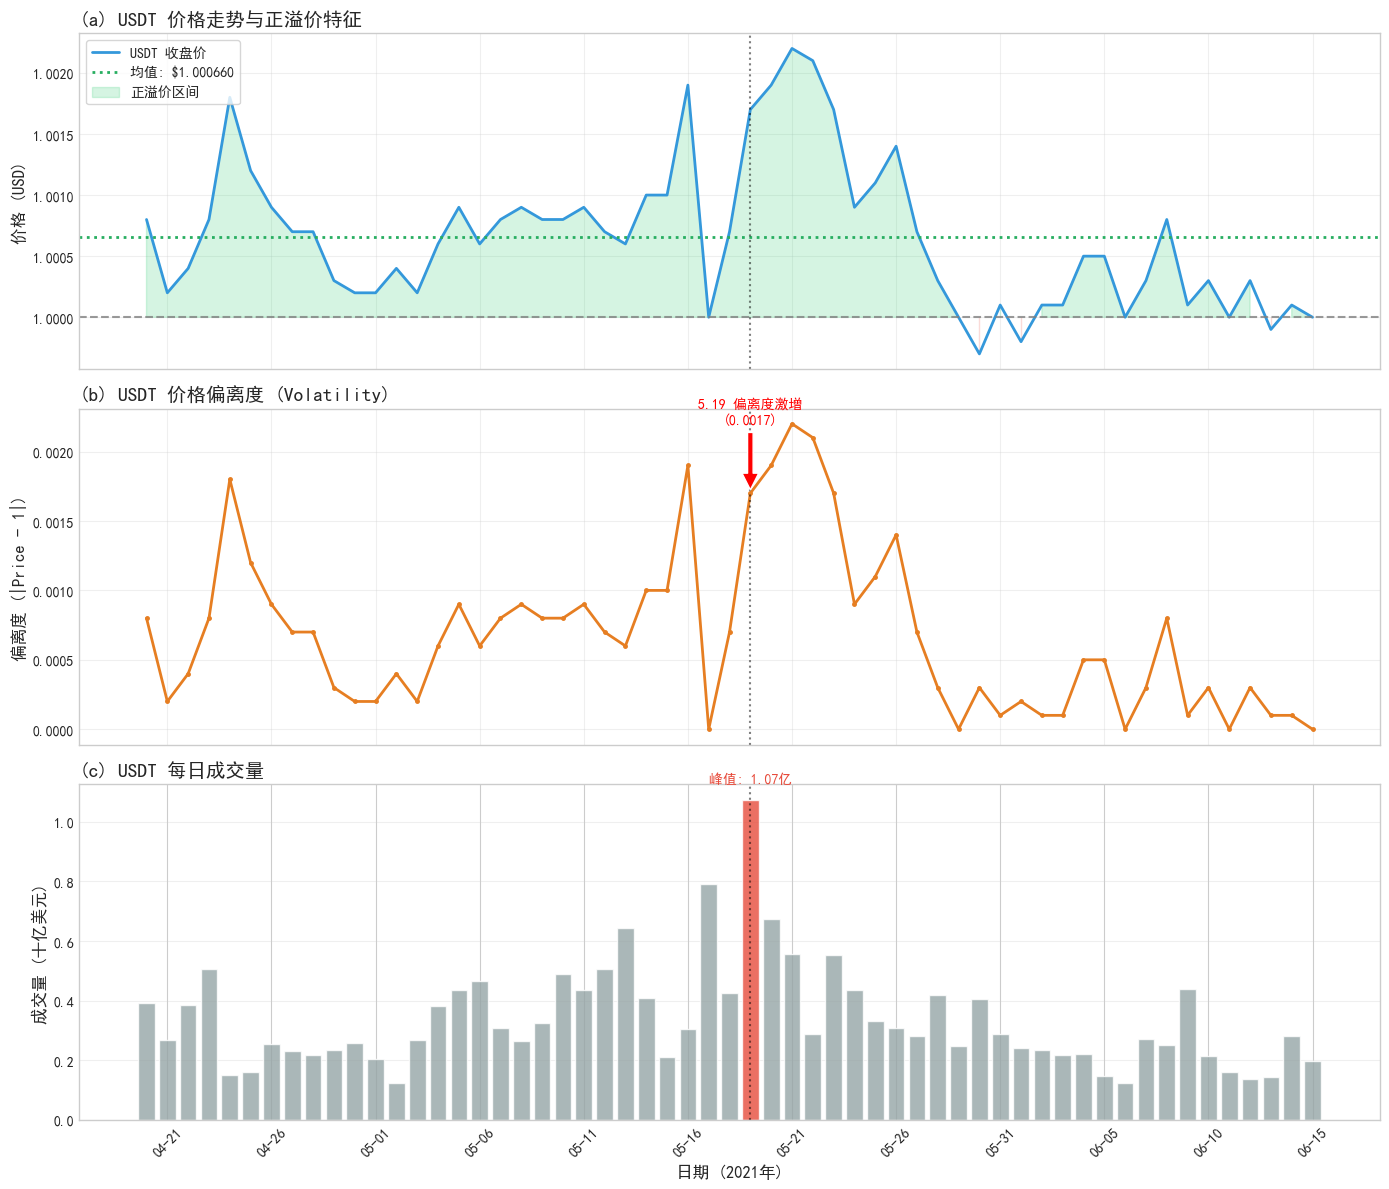

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np

# ==================== 绘图配置 ====================
# 设置风格
sns.set_style("whitegrid")
# 字体设置：优先尝试 Mac/Windows 常用中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 准备数据 (确保按时间排序)
plot_df = master_df.sort_values('Date').copy()
# 将成交量转换为“亿”为单位，方便阅读
plot_df['Volume_Billion'] = plot_df['USDT_Volume'] / 1e9 

# 创建画布：3行1列
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ==================== 子图 1: USDT 价格与正溢价 ====================
# 绘制价格线
ax1.plot(plot_df['Date'], plot_df['USDT_Close'], 
         color='#3498db', linewidth=2, label='USDT 收盘价')

# 绘制锚定线 (1.00)
ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)

# 绘制均值线
mean_price = plot_df['USDT_Close'].mean() # 约 1.000658
ax1.axhline(mean_price, color='#27ae60', linestyle=':', linewidth=2, 
            label=f'均值: ${mean_price:.6f}')

# 填充“正溢价”区域 (价格 > 1.00 的部分)
ax1.fill_between(plot_df['Date'], plot_df['USDT_Close'], 1.00, 
                 where=(plot_df['USDT_Close'] >= 1.00),
                 color='#2ecc71', alpha=0.2, label='正溢价区间')

# 填充“折价”区域 (价格 < 1.00 的部分)
ax1.fill_between(plot_df['Date'], plot_df['USDT_Close'], 1.00, 
                 where=(plot_df['USDT_Close'] < 1.00),
                 color='#e74c3c', alpha=0.2)

ax1.set_ylabel('价格 (USD)', fontsize=12, fontweight='bold')
ax1.set_title('(a) USDT 价格走势与正溢价特征', loc='left', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)

# ==================== 子图 2: 价格偏离度 (Deviation) ====================
# 绘制偏离度
ax2.plot(plot_df['Date'], plot_df['USDT_Deviation'], 
         color='#e67e22', linewidth=2, marker='.', markersize=5)

# 标注 5.19 偏离度激增
crash_date = pd.to_datetime('2021-05-19')
if crash_date in plot_df['Date'].values:
    dev_val = plot_df.loc[plot_df['Date'] == crash_date, 'USDT_Deviation'].values[0]
    ax2.annotate(f'5.19 偏离度激增\n({dev_val:.4f})', 
                 xy=(crash_date, dev_val), xytext=(crash_date, dev_val + 0.0005),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 ha='center', fontsize=10, color='red', fontweight='bold')

ax2.set_ylabel('偏离度 (|Price - 1|)', fontsize=12, fontweight='bold')
ax2.set_title('(b) USDT 价格偏离度 (Volatility)', loc='left', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# ==================== 子图 3: 成交量 (Volume) ====================
# 绘制成交量柱状图
colors = ['#95a5a6'] * len(plot_df) # 默认灰色
# 找到 5.19 的索引，将其标红
try:
    idx_519 = plot_df[plot_df['Date'] == crash_date].index[0]
    # 注意：reset_index后的索引可能不连续，这里用iloc位置更安全
    loc_519 = plot_df.index.get_loc(idx_519)
    colors[loc_519] = '#e74c3c' # 红色
except:
    pass

ax3.bar(plot_df['Date'], plot_df['Volume_Billion'], color=colors, alpha=0.8, width=0.8)

# 标注峰值
if crash_date in plot_df['Date'].values:
    vol_val = plot_df.loc[plot_df['Date'] == crash_date, 'Volume_Billion'].values[0]
    ax3.text(crash_date, vol_val + 0.05, f'峰值: {vol_val:.2f}亿', 
             ha='center', va='bottom', color='#e74c3c', fontweight='bold')

ax3.set_ylabel('成交量 (十亿美元)', fontsize=12, fontweight='bold')
ax3.set_title('(c) USDT 每日成交量', loc='left', fontsize=14, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

# ==================== 全局设置 ====================
# 统一标记 5.19 事件线
for ax in [ax1, ax2, ax3]:
    ax.axvline(crash_date, color='black', linestyle=':', alpha=0.5, linewidth=1.5)

# 设置 X 轴格式
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xlabel('日期 (2021年)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Market_Overview_Panel.png', dpi=300)
print("✅ 图表已保存: Market_Overview_Panel.png")
plt.show() 

✅ 图表已保存: Market_Overview_Panel_BTC_in_B.png


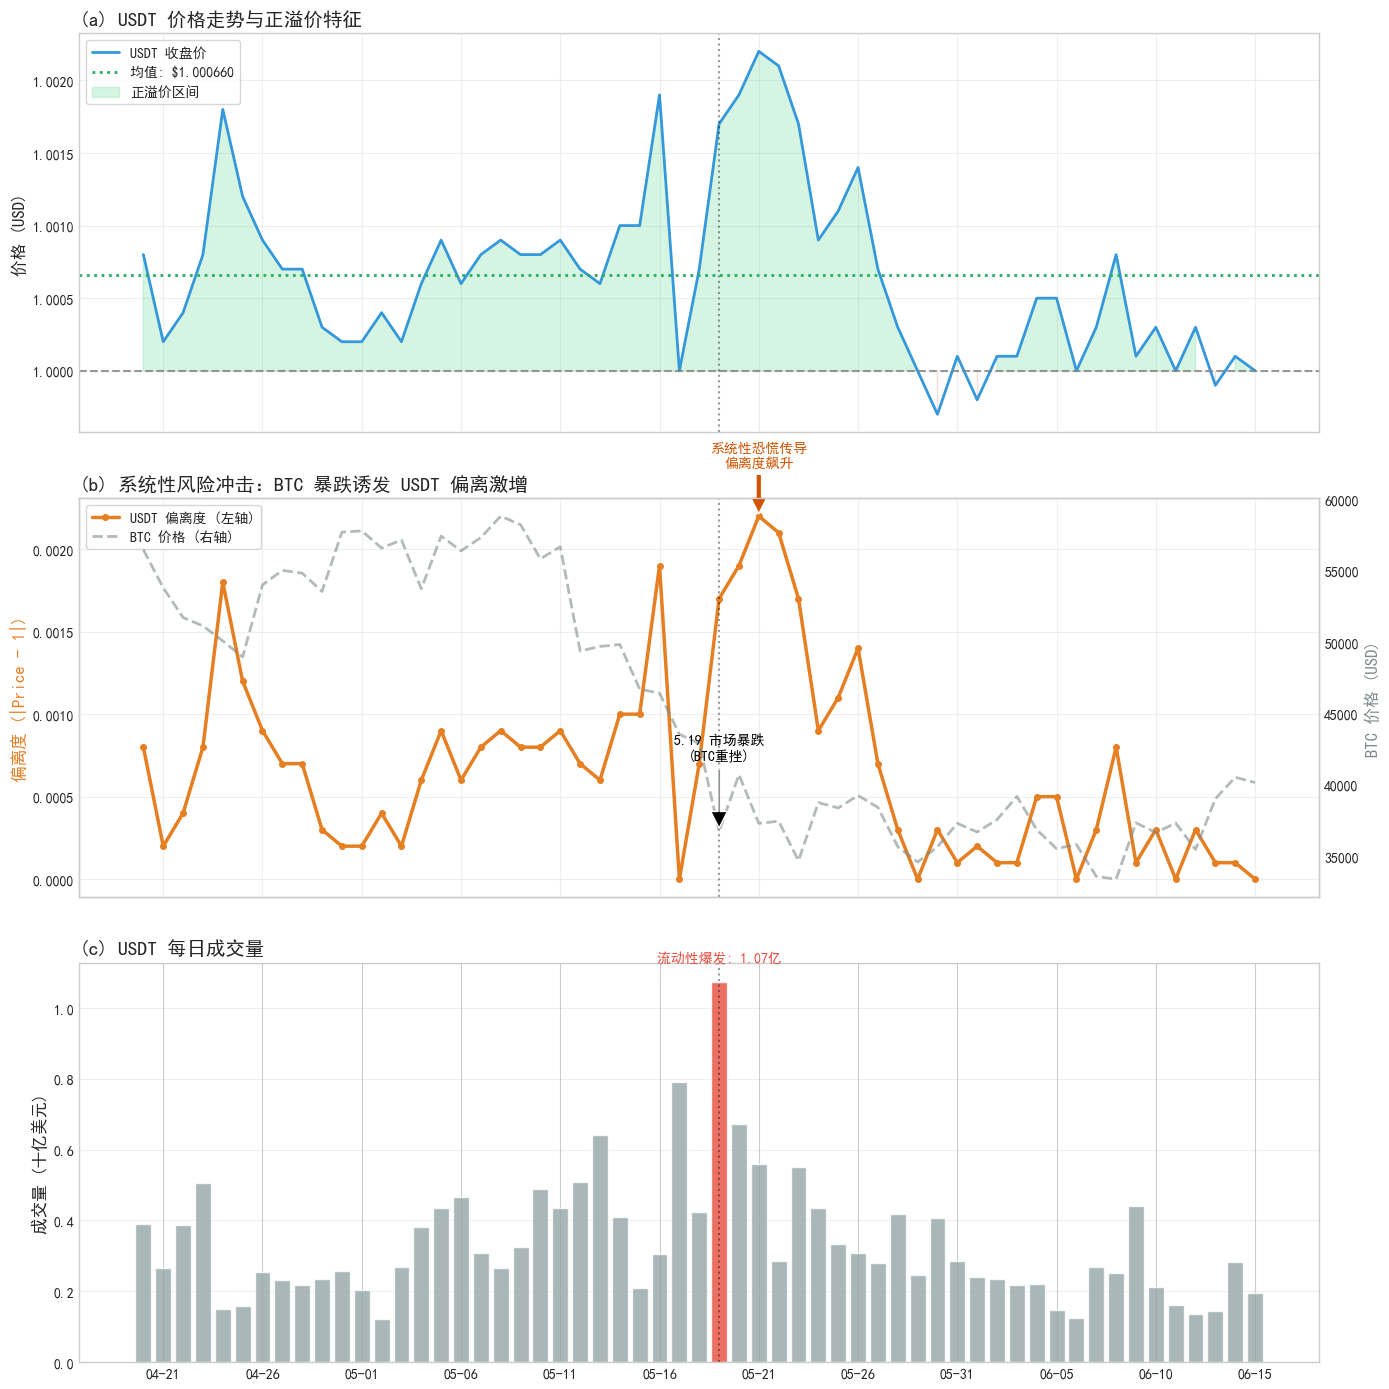

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np

# ==================== 绘图配置 ====================
# 设置风格
sns.set_style("whitegrid")
# 字体设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 准备数据
plot_df = master_df.sort_values('Date').copy()
plot_df['Volume_Billion'] = plot_df['USDT_Volume'] / 1e9 

# 创建画布
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# ==================== 子图 1: USDT 价格与正溢价 (保持不变) ====================
ax1.plot(plot_df['Date'], plot_df['USDT_Close'], 
         color='#3498db', linewidth=2, label='USDT 收盘价')
ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
mean_price = plot_df['USDT_Close'].mean()
ax1.axhline(mean_price, color='#27ae60', linestyle=':', linewidth=2, 
            label=f'均值: ${mean_price:.6f}')
ax1.fill_between(plot_df['Date'], plot_df['USDT_Close'], 1.00, 
                 where=(plot_df['USDT_Close'] >= 1.00),
                 color='#2ecc71', alpha=0.2, label='正溢价区间')
ax1.fill_between(plot_df['Date'], plot_df['USDT_Close'], 1.00, 
                 where=(plot_df['USDT_Close'] < 1.00),
                 color='#e74c3c', alpha=0.2)
ax1.set_ylabel('价格 (USD)', fontsize=12, fontweight='bold')
ax1.set_title('(a) USDT 价格走势与正溢价特征', loc='left', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)

# ==================== 子图 2: 偏离度 vs BTC 暴跌 (双Y轴核心修改) ====================

# --- 左轴：USDT 偏离度 ---
ln1 = ax2.plot(plot_df['Date'], plot_df['USDT_Deviation'], 
               color='#e67e22', linewidth=2.5, marker='.', markersize=8, 
               label='USDT 偏离度 (左轴)')

# --- 右轴：BTC 价格 ---
ax2_twin = ax2.twinx()
ln2 = ax2_twin.plot(plot_df['Date'], plot_df['BTC_Close'], 
                    color='#7f8c8d', linestyle='--', linewidth=2, alpha=0.6, 
                    label='BTC 价格 (右轴)')

# --- 标注 5.19 事件 ---
crash_date = pd.to_datetime('2021-05-19')
if crash_date in plot_df['Date'].values:
    # 1. 标注 BTC 暴跌
    btc_val = plot_df.loc[plot_df['Date'] == crash_date, 'BTC_Close'].values[0]
    ax2_twin.annotate('5.19 市场暴跌\n(BTC重挫)', 
                      xy=(crash_date, btc_val), 
                      xytext=(crash_date, btc_val + 5000),
                      arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                      ha='center', fontsize=10, fontweight='bold', color='black')
    
    # 2. 标注 偏离度激增 (稍微错开一点位置，避免重叠)
    dev_val = plot_df.loc[plot_df['Date'] == crash_date, 'USDT_Deviation'].values[0]
    # 找一下峰值 (5.21)
    peak_date = pd.to_datetime('2021-05-21')
    peak_val = plot_df.loc[plot_df['Date'] == peak_date, 'USDT_Deviation'].values[0]
    
    ax2.annotate(f'系统性恐慌传导\n偏离度飙升', 
                 xy=(peak_date, peak_val), 
                 xytext=(peak_date, peak_val + 0.0003),
                 arrowprops=dict(facecolor='#d35400', shrink=0.05),
                 ha='center', fontsize=10, fontweight='bold', color='#d35400')

# 设置轴标签
ax2.set_ylabel('偏离度 (|Price - 1|)', fontsize=12, fontweight='bold', color='#e67e22')
ax2_twin.set_ylabel('BTC 价格 (USD)', fontsize=12, fontweight='bold', color='#7f8c8d')
ax2.set_title('(b) 系统性风险冲击：BTC 暴跌诱发 USDT 偏离激增', loc='left', fontsize=14, fontweight='bold')

# 合并图例
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', frameon=True)

ax2.grid(True, alpha=0.3)
ax2_twin.grid(False) # 关闭右轴网格

# ==================== 子图 3: 成交量 (保持不变) ====================
colors = ['#95a5a6'] * len(plot_df)
try:
    idx_519 = plot_df[plot_df['Date'] == crash_date].index[0]
    loc_519 = plot_df.index.get_loc(idx_519)
    colors[loc_519] = '#e74c3c'
except:
    pass

ax3.bar(plot_df['Date'], plot_df['Volume_Billion'], color=colors, alpha=0.8, width=0.8)

if crash_date in plot_df['Date'].values:
    vol_val = plot_df.loc[plot_df['Date'] == crash_date, 'Volume_Billion'].values[0]
    ax3.text(crash_date, vol_val + 0.05, f'流动性爆发: {vol_val:.2f}亿', 
             ha='center', va='bottom', color='#e74c3c', fontweight='bold')

ax3.set_ylabel('成交量 (十亿美元)', fontsize=12, fontweight='bold')
ax3.set_title('(c) USDT 每日成交量', loc='left', fontsize=14, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

# ==================== 全局设置 ====================
for ax in [ax1, ax2, ax3]:
    ax.axvline(crash_date, color='black', linestyle=':', alpha=0.4, linewidth=1.5)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xlabel('日期 (2021年)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('Market_Overview_Panel_BTC_in_B.png', dpi=300)
print("✅ 图表已保存: Market_Overview_Panel_BTC_in_B.png")
plt.show()

In [9]:
# 只显示时间特征列
master_df[['Date', 'DayOfWeek', 'IsWeekend', 'DayOfMonth', 'WeekOfYear']].head() 

,Date,DayOfWeek,IsWeekend,DayOfMonth,WeekOfYear
0,2021-04-20,1,0,20,16
1,2021-04-21,2,0,21,16
2,2021-04-22,3,0,22,16
3,2021-04-23,4,0,23,16
4,2021-04-24,5,1,24,16


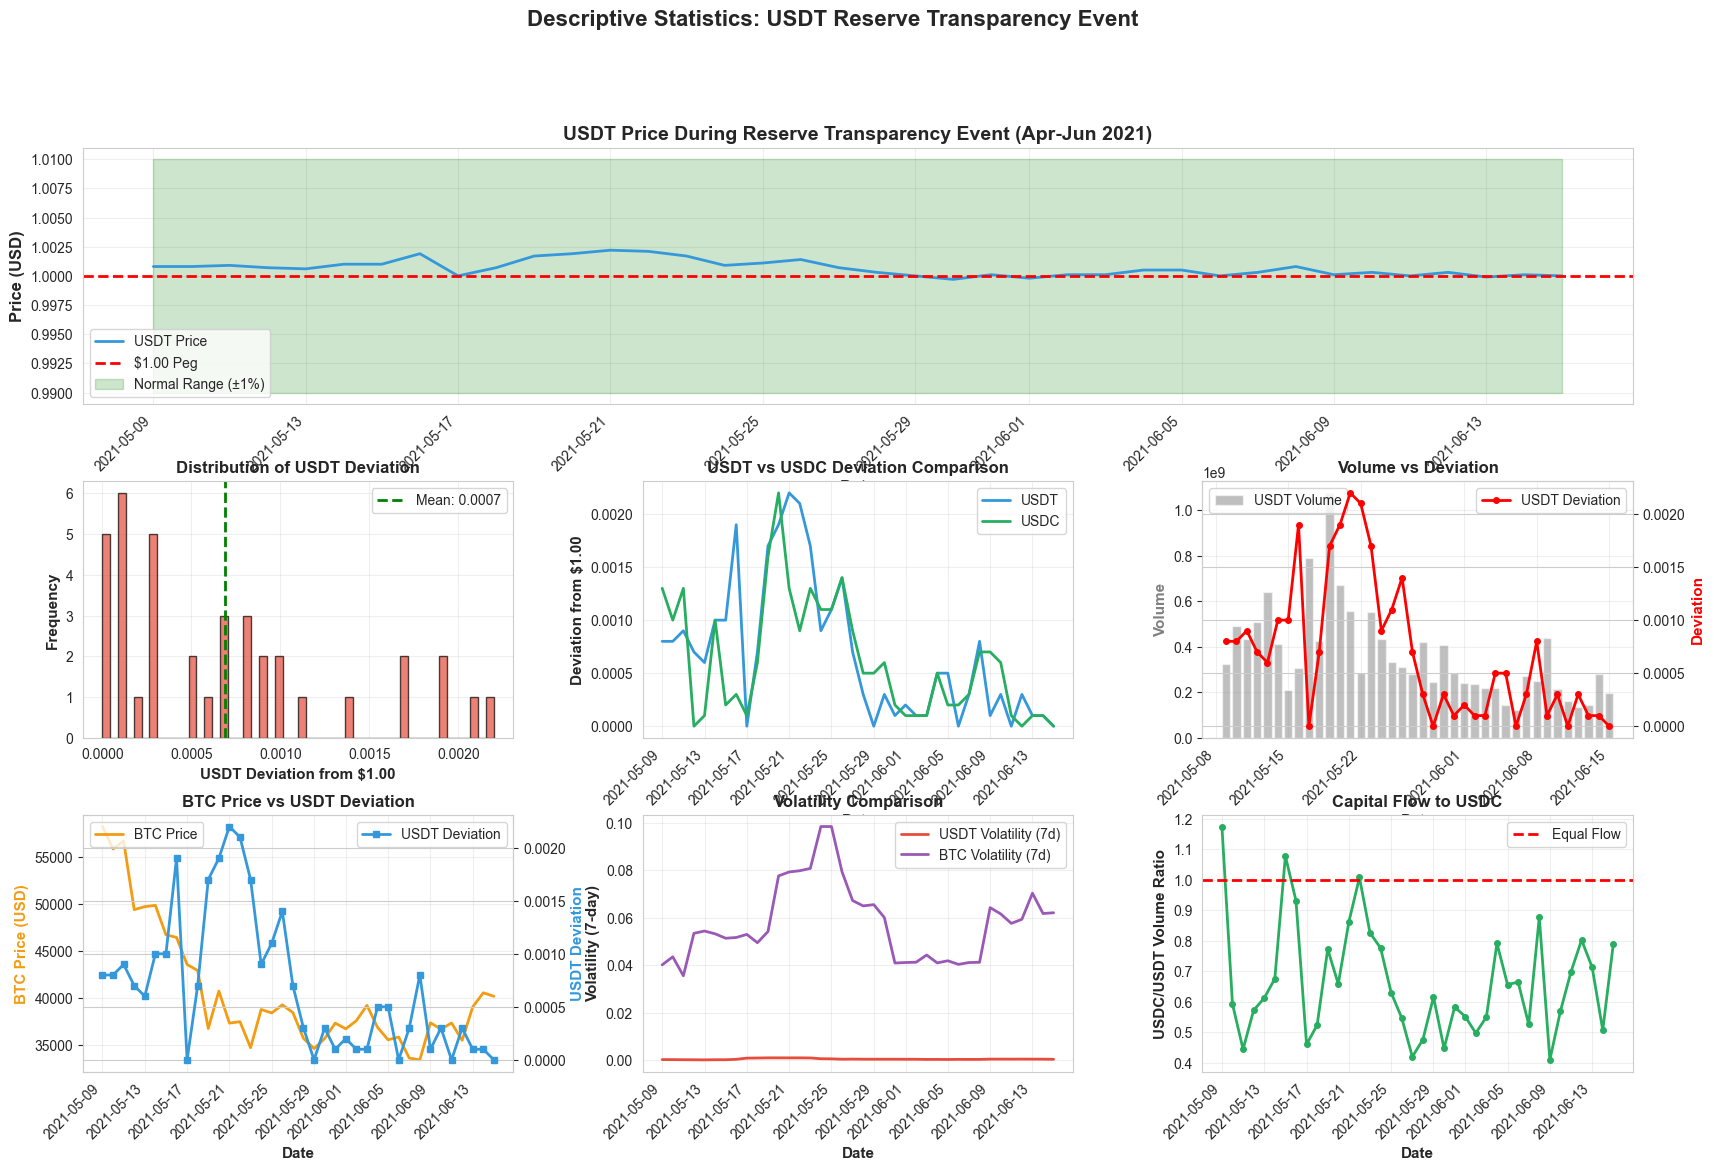

描述性统计摘要
       USDT_Close  USDT_Deviation   USDT_Volume     BTC_Close  USDC_Deviation
count   38.000000       38.000000  3.800000e+01     38.000000       38.000000
mean     1.000658        0.000689  3.599979e+08  40505.071053        0.000613
std      0.000686        0.000653  1.987057e+08   6517.452890        0.000548
min      0.999700        0.000000  1.236752e+08  33382.900000        0.000000
25%      1.000100        0.000100  2.236931e+08  36658.950000        0.000100
50%      1.000550        0.000550  2.960958e+08  37967.050000        0.000500
75%      1.000975        0.000975  4.354581e+08  42352.275000        0.001000
max      1.002200        0.002200  1.073871e+09  58238.300000        0.002200

关键事件识别
最大脱锚日期: 2021-05-21 00:00:00
最大脱锚程度: $0.0022
当日USDT价格: $1.0022

最低价格日期: 2021-05-30 00:00:00
最低价格: $0.9997


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# ==================== 1. 描述性统计可视化 ====================
def plot_descriptive_stats(df):
    """描述性统计可视化"""
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1.1 USDT价格时间序列
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df['Date'], df['USDT_Close'], linewidth=2, color='#3498db', label='USDT Price')
    ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='$1.00 Peg')
    ax1.fill_between(df['Date'], 0.99, 1.01, alpha=0.2, color='green', label='Normal Range (±1%)')
    ax1.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Price (USD)', fontweight='bold', fontsize=12)
    ax1.set_title('USDT Price During Reserve Transparency Event (Apr-Jun 2021)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.2 USDT脱锚程度分布
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(df['USDT_Deviation'], bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
    ax2.axvline(df['USDT_Deviation'].mean(), color='green', linestyle='--', 
                linewidth=2, label=f'Mean: {df["USDT_Deviation"].mean():.4f}')
    ax2.set_xlabel('USDT Deviation from $1.00', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=11)
    ax2.set_title('Distribution of USDT Deviation', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 1.3 USDT vs USDC 对比
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(df['Date'], df['USDT_Deviation'], label='USDT', linewidth=2, color='#3498db')
    ax3.plot(df['Date'], df['USDC_Deviation'], label='USDC', linewidth=2, color='#27ae60')
    ax3.set_xlabel('Date', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Deviation from $1.00', fontweight='bold', fontsize=11)
    ax3.set_title('USDT vs USDC Deviation Comparison', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.4 成交量变化
    ax4 = fig.add_subplot(gs[1, 2])
    ax4_twin = ax4.twinx()
    ax4.bar(df['Date'], df['USDT_Volume'], alpha=0.5, color='gray', label='USDT Volume')
    ax4_twin.plot(df['Date'], df['USDT_Deviation'], color='red', linewidth=2, 
                  marker='o', markersize=4, label='USDT Deviation')
    ax4.set_xlabel('Date', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Volume', fontweight='bold', fontsize=11, color='gray')
    ax4_twin.set_ylabel('Deviation', fontweight='bold', fontsize=11, color='red')
    ax4.set_title('Volume vs Deviation', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    ax4.grid(alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.5 BTC价格影响
    ax5 = fig.add_subplot(gs[2, 0])
    ax5_twin = ax5.twinx()
    ax5.plot(df['Date'], df['BTC_Close'], color='#f39c12', linewidth=2, label='BTC Price')
    ax5_twin.plot(df['Date'], df['USDT_Deviation'], color='#3498db', linewidth=2, 
                  marker='s', markersize=4, label='USDT Deviation')
    ax5.set_xlabel('Date', fontweight='bold', fontsize=11)
    ax5.set_ylabel('BTC Price (USD)', fontweight='bold', fontsize=11, color='#f39c12')
    ax5_twin.set_ylabel('USDT Deviation', fontweight='bold', fontsize=11, color='#3498db')
    ax5.set_title('BTC Price vs USDT Deviation', fontsize=12, fontweight='bold')
    ax5.legend(loc='upper left')
    ax5_twin.legend(loc='upper right')
    ax5.grid(alpha=0.3)
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.6 波动率对比
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.plot(df['Date'], df['USDT_Volatility_7d'], label='USDT Volatility (7d)', 
             linewidth=2, color='#e74c3c')
    ax6.plot(df['Date'], df['BTC_Volatility_7d'], label='BTC Volatility (7d)', 
             linewidth=2, color='#9b59b6')
    ax6.set_xlabel('Date', fontweight='bold', fontsize=11)
    ax6.set_ylabel('Volatility (7-day)', fontweight='bold', fontsize=11)
    ax6.set_title('Volatility Comparison', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 1.7 资金流向指标
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.plot(df['Date'], df['Flow_to_USDC'], linewidth=2, color='#27ae60', marker='o', markersize=4)
    ax7.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Equal Flow')
    ax7.set_xlabel('Date', fontweight='bold', fontsize=11)
    ax7.set_ylabel('USDC/USDT Volume Ratio', fontweight='bold', fontsize=11)
    ax7.set_title('Capital Flow to USDC', fontsize=12, fontweight='bold')
    ax7.legend()
    ax7.grid(alpha=0.3)
    plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Descriptive Statistics: USDT Reserve Transparency Event', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('descriptive_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印描述性统计
    print("="*60)
    print("描述性统计摘要")
    print("="*60)
    stats_summary = df[['USDT_Close', 'USDT_Deviation', 'USDT_Volume', 
                        'BTC_Close', 'USDC_Deviation']].describe()
    print(stats_summary)
    
    # 关键事件识别
    print("\n" + "="*60)
    print("关键事件识别")
    print("="*60)
    max_deviation_idx = df['USDT_Deviation'].idxmax()
    print(f"最大脱锚日期: {df.loc[max_deviation_idx, 'Date']}")
    print(f"最大脱锚程度: ${df.loc[max_deviation_idx, 'USDT_Deviation']:.4f}")
    print(f"当日USDT价格: ${df.loc[max_deviation_idx, 'USDT_Close']:.4f}")
    
    min_price_idx = df['USDT_Close'].idxmin()
    print(f"\n最低价格日期: {df.loc[min_price_idx, 'Date']}")
    print(f"最低价格: ${df.loc[min_price_idx, 'USDT_Close']:.4f}")

# 运行描述性统计可视化
plot_descriptive_stats(master_df.dropna())


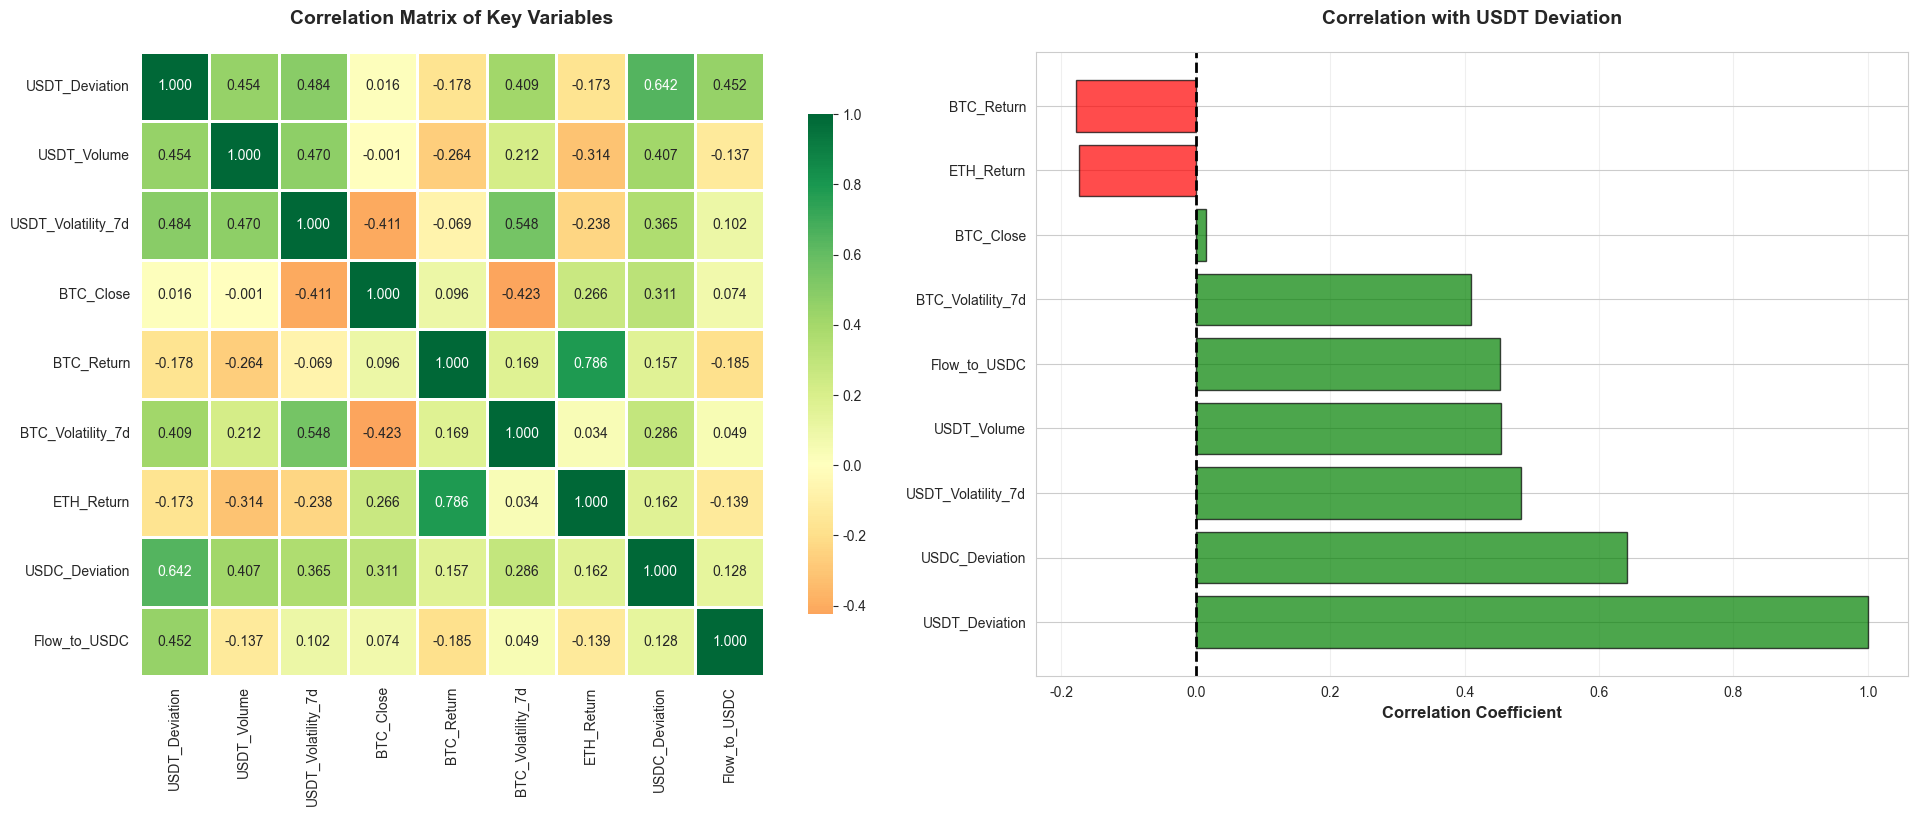


与USDT脱锚程度相关性最高的变量
USDT_Deviation        1.000000
USDC_Deviation        0.642128
USDT_Volatility_7d    0.484411
USDT_Volume           0.453573
Flow_to_USDC          0.452115
BTC_Volatility_7d     0.409474
BTC_Close             0.015553
ETH_Return           -0.173248
BTC_Return           -0.178401
Name: USDT_Deviation, dtype: float64

相关性显著性检验 (p < 0.05)
USDT_Volume                    | 相关系数:  0.4536 | p值: 0.0009 | ✅ 显著
USDT_Volatility_7d             | 相关系数:  0.4844 | p值: 0.0004 | ✅ 显著
BTC_Close                      | 相关系数:  0.0156 | p值: 0.9146 | ❌ 不显著
BTC_Return                     | 相关系数: -0.1784 | p值: 0.2151 | ❌ 不显著
BTC_Volatility_7d              | 相关系数:  0.4095 | p值: 0.0031 | ✅ 显著
ETH_Return                     | 相关系数: -0.1732 | p值: 0.2289 | ❌ 不显著
USDC_Deviation                 | 相关系数:  0.6421 | p值: 0.0000 | ✅ 显著
Flow_to_USDC                   | 相关系数:  0.4521 | p值: 0.0010 | ✅ 显著


In [11]:
# ==================== 2. 相关性分析 ====================
def plot_correlation_analysis(df):
    """相关性分析可视化"""
    # 选择关键变量
    key_vars = [
        'USDT_Deviation', 'USDT_Volume', 'USDT_Volatility_7d',
        'BTC_Close', 'BTC_Return', 'BTC_Volatility_7d',
        'ETH_Return', 'USDC_Deviation', 'Flow_to_USDC'
    ]
    
    df_corr = df[key_vars].dropna()
    
    # 计算相关系数矩阵
    corr_matrix = df_corr.corr()
    
    # 绘制热力图
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 2.1 完整相关性热力图
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[0])
    axes[0].set_title('Correlation Matrix of Key Variables', 
                      fontsize=14, fontweight='bold', pad=20)
    
    # 2.2 与USDT_Deviation的相关性排序
    target_corr = corr_matrix['USDT_Deviation'].sort_values(ascending=False)
    colors = ['green' if x > 0 else 'red' for x in target_corr.values]
    
    axes[1].barh(range(len(target_corr)), target_corr.values, color=colors, 
                 edgecolor='black', alpha=0.7)
    axes[1].set_yticks(range(len(target_corr)))
    axes[1].set_yticklabels(target_corr.index)
    axes[1].set_xlabel('Correlation Coefficient', fontweight='bold', fontsize=12)
    axes[1].set_title('Correlation with USDT Deviation', 
                      fontsize=14, fontweight='bold', pad=20)
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2)
    axes[1].grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印相关性分析
    print("\n" + "="*60)
    print("与USDT脱锚程度相关性最高的变量")
    print("="*60)
    print(target_corr)
    
    # 显著性检验
    print("\n" + "="*60)
    print("相关性显著性检验 (p < 0.05)")
    print("="*60)
    for var in key_vars:
        if var != 'USDT_Deviation':
            corr, p_value = stats.pearsonr(df_corr['USDT_Deviation'], df_corr[var])
            significance = "✅ 显著" if p_value < 0.05 else "❌ 不显著"
            print(f"{var:30s} | 相关系数: {corr:7.4f} | p值: {p_value:.4f} | {significance}")

# 运行相关性分析
plot_correlation_analysis(master_df)


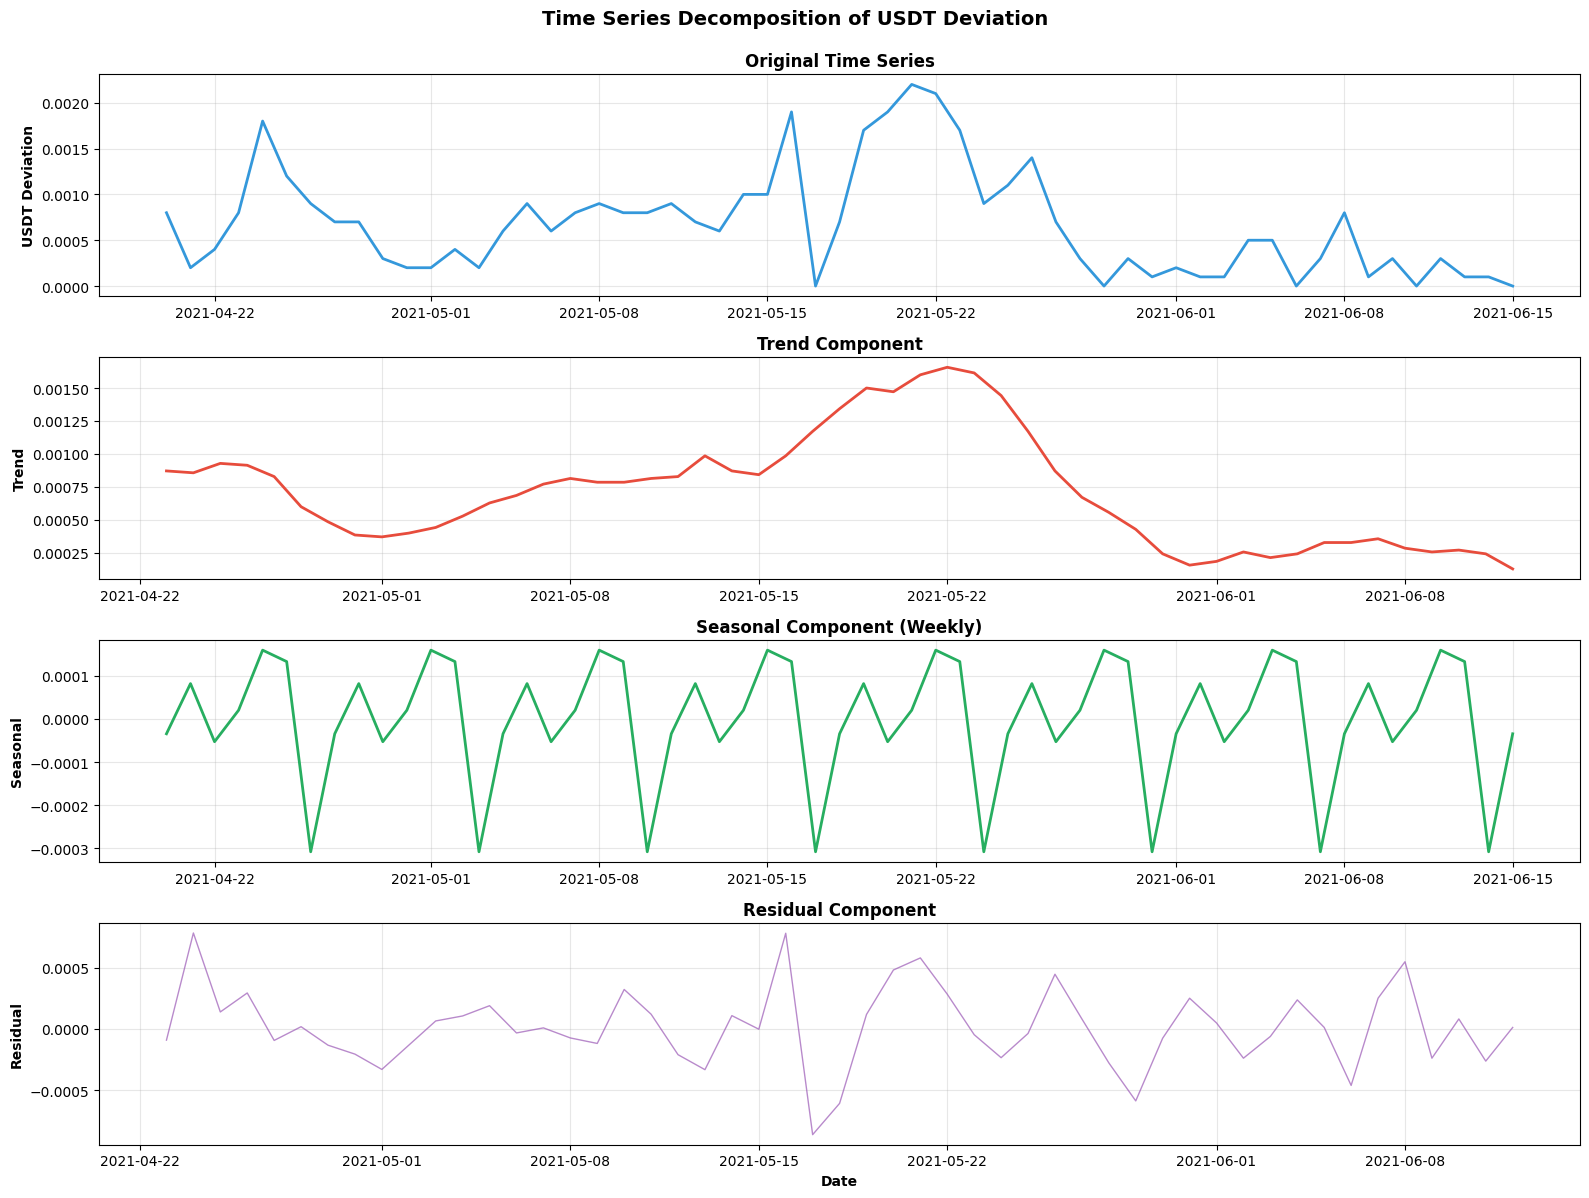

In [10]:
# ==================== 3. 时间序列分解 ====================
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_time_series_decomposition(df):
    """时间序列分解"""
    # 准备数据
    ts_data = df[['Date', 'USDT_Deviation']].dropna().set_index('Date')
    
    # 时间序列分解
    decomposition = seasonal_decompose(ts_data['USDT_Deviation'], 
                                      model='additive', period=7)
    
    # 绘图
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    # 原始序列
    '''
    ### 显示USDT脱锚偏离度的实际时间序列数据:
    Y轴: USDT偏离1美元的幅度（正值表示溢价，负值表示折价）
    X轴: 时间轴
    观察整体趋势、波动模式和异常点
    这是未经处理的原始数据，包含了所有成分
    '''
    axes[0].plot(ts_data.index, ts_data['USDT_Deviation'], linewidth=2, color='#3498db')
    axes[0].set_ylabel('USDT Deviation', fontweight='bold')
    axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # 趋势
    '''
    ### 反映USDT偏离度的长期走势，去除了短期波动:
    显示数据的主要方向性变化
    可以看出USDT偏离度的长期变化趋势
    如果趋势线向上倾斜，说明USDT长期趋于溢价；向下则趋于折价
    平缓的趋势表示相对稳定的脱锚状态
    '''
    axes[1].plot(decomposition.trend.index, decomposition.trend, 
                 linewidth=2, color='#e74c3c')
    axes[1].set_ylabel('Trend', fontweight='bold')
    axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    # 季节性
    '''
    ### 显示每周重复出现的周期性模式（由于设置了period=7）:
    观察是否存在每周重复的模式
    Y轴数值表示相对于平均水平的偏差
    可以识别一周中哪几天USDT更容易偏离
    周期性的波动表明可能存在规律性的市场行为
    '''
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, 
                 linewidth=2, color='#27ae60')
    axes[2].set_ylabel('Seasonal', fontweight='bold')
    axes[2].set_title('Seasonal Component (Weekly)', fontsize=12, fontweight='bold')
    axes[2].grid(alpha=0.3)
    
    # 残差
    '''
    ### 去除趋势和季节性后的随机波动部分:
    显示无法用趋势和季节性解释的随机变化
    理想情况下应该围绕0线上下随机波动
    如果残差有明显模式，说明模型可能遗漏了某些因素
    残差的大小反映模型拟合的好坏
    '''
    axes[3].plot(decomposition.resid.index, decomposition.resid, 
                 linewidth=1, color='#9b59b6', alpha=0.7)
    axes[3].set_ylabel('Residual', fontweight='bold')
    axes[3].set_xlabel('Date', fontweight='bold')
    axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
    axes[3].grid(alpha=0.3)
    
    plt.suptitle('Time Series Decomposition of USDT Deviation', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png', dpi=300, bbox_inches='tight')
    plt.show()

# 运行时间序列分解
plot_time_series_decomposition(master_df)


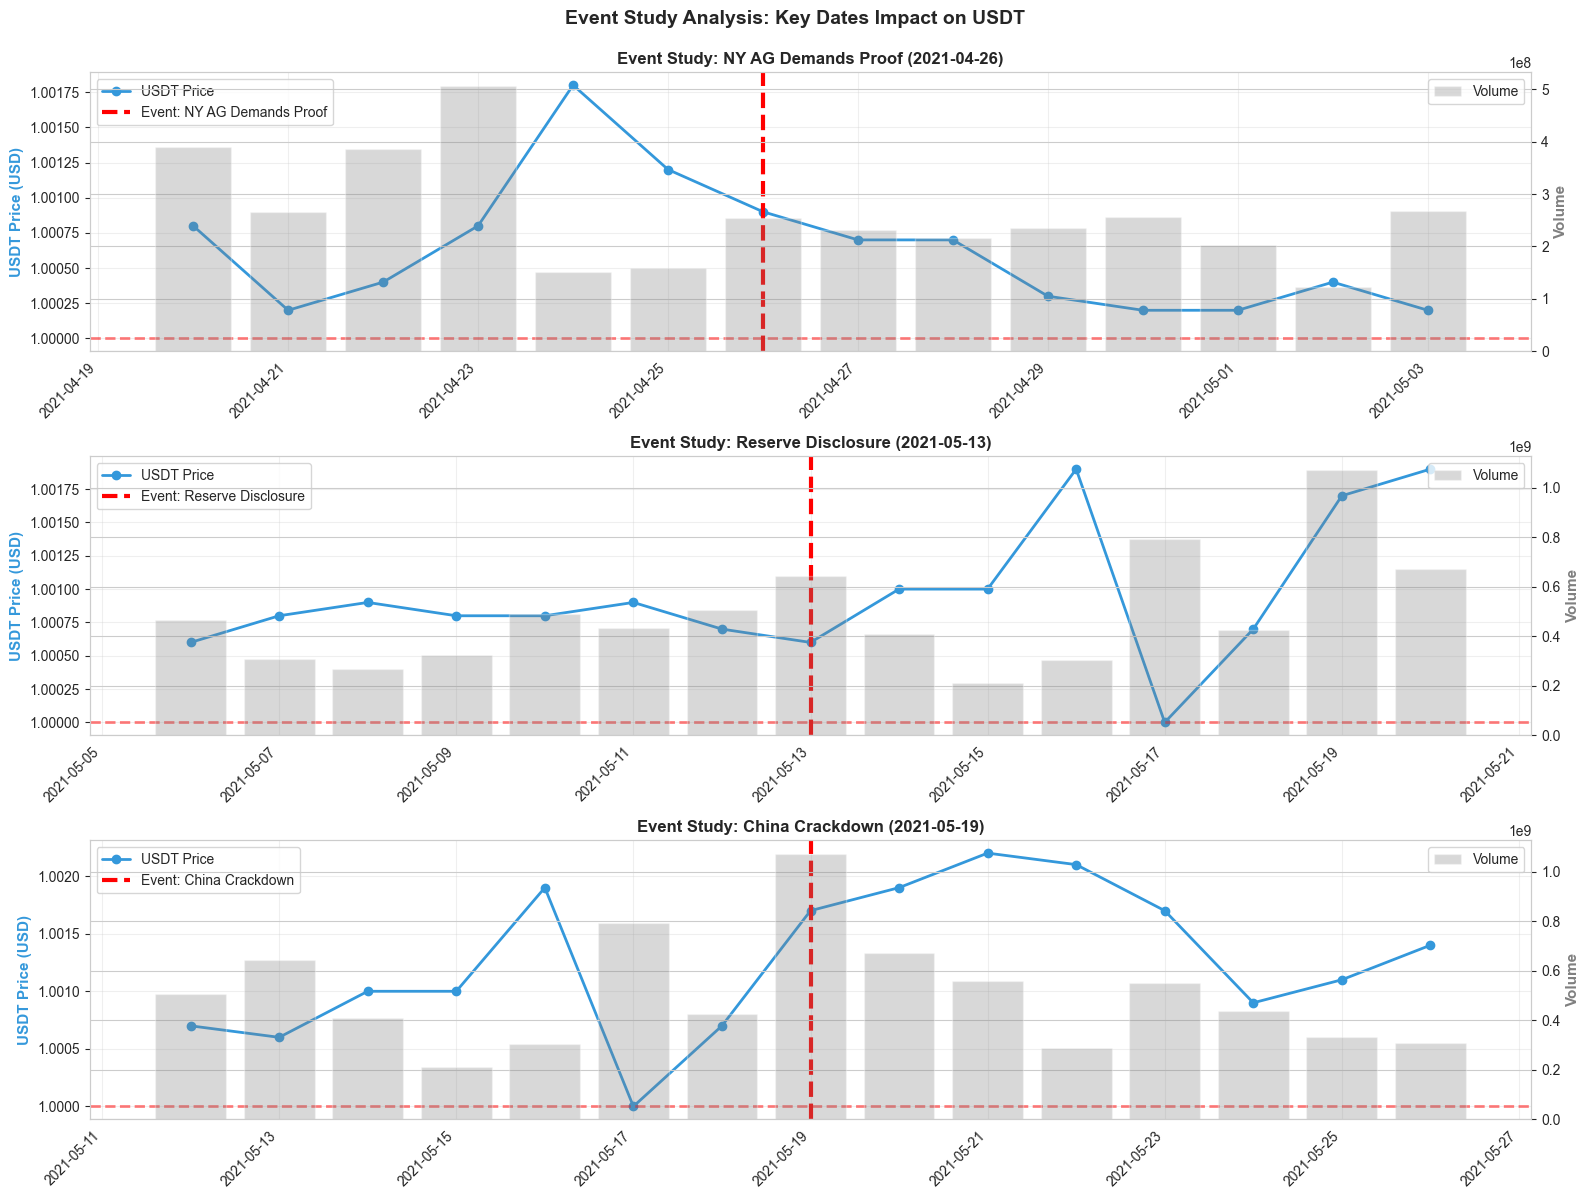


事件窗口累计异常收益 (CAR)

NY AG Demands Proof (2021-04-26):
  累计异常偏离 (CAR): 0.001635
  平均异常偏离: 0.000234
  最大异常偏离: 0.001119

Reserve Disclosure (2021-05-13):
  累计异常偏离 (CAR): 0.002135
  平均异常偏离: 0.000305
  最大异常偏离: 0.001219

China Crackdown (2021-05-19):
  累计异常偏离 (CAR): 0.005735
  平均异常偏离: 0.000819
  最大异常偏离: 0.001519


In [ ]:
# ==================== 4. 事件研究法 ====================
def plot_event_study(df):
    """事件研究法：关键日期前后的价格变化"""
    # 定义关键事件日期
    events = {
        '2021-04-26': 'NY AG Demands Proof',
        '2021-05-13': 'Reserve Disclosure',
        '2021-05-19': 'China Crackdown'
    }
    
    fig, axes = plt.subplots(len(events), 1, figsize=(16, 12))
    
    for idx, (event_date, event_name) in enumerate(events.items()):
        event_date = pd.to_datetime(event_date)
        
        # 事件前后7天
        window_start = event_date - pd.Timedelta(days=7)
        window_end = event_date + pd.Timedelta(days=7)
        
        event_window = df[(df['Date'] >= window_start) & (df['Date'] <= window_end)]
        
        # 绘制
        ax = axes[idx]
        ax_twin = ax.twinx()
        
        # USDT价格
        ax.plot(event_window['Date'], event_window['USDT_Close'], 
                linewidth=2, color='#3498db', marker='o', label='USDT Price')
        ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5)
        ax.axvline(x=event_date, color='red', linestyle='--', linewidth=3, 
                   label=f'Event: {event_name}')
        
        # 成交量
        ax_twin.bar(event_window['Date'], event_window['USDT_Volume'], 
                    alpha=0.3, color='gray', label='Volume')
        
        ax.set_ylabel('USDT Price (USD)', fontweight='bold', fontsize=11, color='#3498db')
        ax_twin.set_ylabel('Volume', fontweight='bold', fontsize=11, color='gray')
        ax.set_title(f'Event Study: {event_name} ({event_date.date()})', 
                     fontsize=12, fontweight='bold')
        ax.legend(loc='upper left')
        ax_twin.legend(loc='upper right')
        ax.grid(alpha=0.3)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Event Study Analysis: Key Dates Impact on USDT', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('event_study_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 计算事件窗口的累计异常收益
    print("\n" + "="*60)
    print("事件窗口累计异常收益 (CAR)")
    print("="*60)
    
    for event_date, event_name in events.items():
        event_date = pd.to_datetime(event_date)
        window_start = event_date - pd.Timedelta(days=3)
        window_end = event_date + pd.Timedelta(days=3)
        
        event_window = df[(df['Date'] >= window_start) & (df['Date'] <= window_end)]
        
        # 计算异常收益（实际偏离 - 正常偏离）
        normal_deviation = df['USDT_Deviation'].mean()
        abnormal_returns = event_window['USDT_Deviation'] - normal_deviation
        car = abnormal_returns.sum()
        
        print(f"\n{event_name} ({event_date.date()}):")
        print(f"  累计异常偏离 (CAR): {car:.6f}")
        print(f"  平均异常偏离: {abnormal_returns.mean():.6f}")
        print(f"  最大异常偏离: {abnormal_returns.max():.6f}")

# 运行事件研究
plot_event_study(master_df)


In [21]:
# # ==================== 整合舆情数据 ====================
# # 假设你已经有了 FinBERT 分析的结果
# # df_sentiment = pd.read_csv('tweets_with_sentiment_finbert.csv')

# # 如果有舆情数据，进行合并
# def merge_sentiment_data(master_df, sentiment_df):
#     """合并舆情数据"""
#     # 按日期聚合舆情数据
#     daily_sentiment = sentiment_df.groupby('Date').agg({
#         'polarity': 'mean',
#         'subjectivity': 'mean',
#         'weighted_sentiment': 'mean',
#         'weighted_sentiment_robust': 'mean',
#         'total_engagement': 'sum'
#     }).reset_index()
    
#     # 重命名列
#     daily_sentiment.columns = [
#         'Date', 
#         'Sentiment_Polarity', 
#         'Sentiment_Subjectivity',
#         'Sentiment_Academic_SMI',
#         'Sentiment_Robust_SMI',
#         'Total_Engagement'
#     ]
    
#     # 转换日期格式
#     daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
    
#     # 合并
#     master_df = pd.merge(master_df, daily_sentiment, on='Date', how='left')
    
#     # 创建舆情相关特征
#     master_df['Sentiment_Change'] = master_df['Sentiment_Academic_SMI'].diff()
#     master_df['Sentiment_MA3'] = master_df['Sentiment_Academic_SMI'].rolling(window=3).mean()
#     master_df['Sentiment_MA7'] = master_df['Sentiment_Academic_SMI'].rolling(window=7).mean()
    
#     # 舆情 × 价格偏离交互特征
#     master_df['Sentiment_x_Deviation'] = master_df['Sentiment_Academic_SMI'] * master_df['USDT_Deviation']
    
#     return master_df

# # 如果有舆情数据，取消下面的注释
# # master_df = merge_sentiment_data(master_df, df_FinBERT) 


In [15]:
# # ==================== 特征选择 ====================
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.feature_selection import SelectKBest, f_regression
# import warnings
# warnings.filterwarnings('ignore')

# # 删除缺失值（由于滞后和滚动窗口产生）
# df_model = master_df.dropna().copy()

# print(f"\n删除缺失值后数据量: {len(df_model)}")

# # 定义特征和目标变量
# target = 'USDT_Deviation'  # 目标变量：USDT 脱锚程度

# # 排除的列
# exclude_cols = ['Date', 'USDT_Open', 'USDT_High', 'USDT_Low', 'USDT_Close', 
#                 'USDT_Deviation', 'USDT_Deviation_Pct', 'USDT_Premium',
#                 'Currency']

# # 获取特征列
# feature_cols = [col for col in df_model.columns if col not in exclude_cols]

# print(f"\n可用特征数量: {len(feature_cols)}")
# print(f"特征列表: {feature_cols[:10]}...")  # 显示前10个

# # 准备数据
# X = df_model[feature_cols]
# y = df_model[target]

# # 方法1：随机森林特征重要性
# rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# rf.fit(X, y)

# # 获取特征重要性
# feature_importance = pd.DataFrame({
#     'Feature': feature_cols,
#     'Importance': rf.feature_importances_
# }).sort_values('Importance', ascending=False)

# print(f"\nTop 20 重要特征:")
# print(feature_importance.head(20))

# # 可视化特征重要性
# plt.figure(figsize=(12, 8))
# plt.barh(feature_importance.head(20)['Feature'], 
#          feature_importance.head(20)['Importance'])
# plt.xlabel('Importance', fontsize=12)
# plt.title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.savefig('feature_importance.png', dpi=300)
# plt.show()

# # 方法2：相关性分析
# correlation_matrix = df_model[feature_cols + [target]].corr()
# target_correlation = correlation_matrix[target].sort_values(ascending=False)

# print(f"\n与目标变量相关性最高的特征:")
# print(target_correlation.head(20))


In [16]:
# # ==================== 模型构建 ====================
# from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import xgboost as xgb

# # ========== 1. 数据分割（时间序列分割）==========
# # 不能随机分割，要保持时间顺序
# train_size = int(len(df_model) * 0.8)
# train_df = df_model.iloc[:train_size]
# test_df = df_model.iloc[train_size:]

# X_train = train_df[feature_cols]
# y_train = train_df[target]
# X_test = test_df[feature_cols]
# y_test = test_df[target]

# print(f"\n训练集大小: {len(X_train)}")
# print(f"测试集大小: {len(X_test)}")
# print(f"训练集日期范围: {train_df['Date'].min()} 到 {train_df['Date'].max()}")
# print(f"测试集日期范围: {test_df['Date'].min()} 到 {test_df['Date'].max()}")

# # ========== 2. 特征标准化 ==========
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # ========== 3. 模型训练与评估 ==========
# models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge Regression': Ridge(alpha=1.0),
#     'Lasso Regression': Lasso(alpha=0.001),
#     'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
#     'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# }

# results = []

# for name, model in models.items():
#     print(f"\n{'='*50}")
#     print(f"训练模型: {name}")
#     print(f"{'='*50}")
    
#     # 训练模型
#     if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
#         model.fit(X_train_scaled, y_train)
#         y_pred = model.predict(X_test_scaled)
#     else:
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
    
#     # 评估指标
#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     mae = mean_absolute_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
    
#     # MAPE (平均绝对百分比误差)
#     mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
#     print(f"RMSE: {rmse:.6f}")
#     print(f"MAE: {mae:.6f}")
#     print(f"R²: {r2:.4f}")
#     print(f"MAPE: {mape:.2f}%")
    
#     results.append({
#         'Model': name,
#         'RMSE': rmse,
#         'MAE': mae,
#         'R²': r2,
#         'MAPE': mape
#     })

# # 结果对比
# results_df = pd.DataFrame(results).sort_values('RMSE')
# print(f"\n{'='*50}")
# print("模型性能对比:")
# print(f"{'='*50}")
# print(results_df.to_string(index=False))

# # 保存结果
# results_df.to_csv('model_comparison.csv', index=False)


In [17]:
# # ==================== 最佳模型分析 ====================
# # 选择表现最好的模型（假设是 XGBoost）
# best_model = xgb.XGBRegressor(
#     n_estimators=200,
#     max_depth=5,
#     learning_rate=0.05,
#     random_state=42,
#     n_jobs=-1
# )

# best_model.fit(X_train, y_train)
# y_pred_best = best_model.predict(X_test)

# # ========== 1. 预测 vs 实际值可视化 ==========
# plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
# plt.plot(test_df['Date'], y_test.values, label='Actual', marker='o', linewidth=2)
# plt.plot(test_df['Date'], y_pred_best, label='Predicted', marker='s', linewidth=2, alpha=0.7)
# plt.xlabel('Date', fontsize=12, fontweight='bold')
# plt.ylabel('USDT Deviation', fontsize=12, fontweight='bold')
# plt.title('Actual vs Predicted USDT Deviation', fontsize=14, fontweight='bold')
# plt.legend()
# plt.xticks(rotation=45)
# plt.grid(alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.scatter(y_test, y_pred_best, alpha=0.6, edgecolors='black')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
#          'r--', linewidth=2, label='Perfect Prediction')
# plt.xlabel('Actual USDT Deviation', fontsize=12, fontweight='bold')
# plt.ylabel('Predicted USDT Deviation', fontsize=12, fontweight='bold')
# plt.title('Prediction Scatter Plot', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('model_prediction_analysis.png', dpi=300)
# plt.show()

# # ========== 2. 残差分析 ==========
# residuals = y_test - y_pred_best

# plt.figure(figsize=(14, 5))

# plt.subplot(1, 3, 1)
# plt.scatter(y_pred_best, residuals, alpha=0.6, edgecolors='black')
# plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
# plt.xlabel('Predicted Values', fontsize=12, fontweight='bold')
# plt.ylabel('Residuals', fontsize=12, fontweight='bold')
# plt.title('Residual Plot', fontsize=14, fontweight='bold')
# plt.grid(alpha=0.3)

# plt.subplot(1, 3, 2)
# plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
# plt.xlabel('Residuals', fontsize=12, fontweight='bold')
# plt.ylabel('Frequency', fontsize=12, fontweight='bold')
# plt.title('Residual Distribution', fontsize=14, fontweight='bold')
# plt.grid(alpha=0.3)

# plt.subplot(1, 3, 3)
# from scipy import stats
# stats.probplot(residuals, dist="norm", plot=plt)
# plt.title('Q-Q Plot', fontsize=14, fontweight='bold')
# plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('residual_analysis.png', dpi=300)
# plt.show()

# # ========== 3. 特征重要性（XGBoost）==========
# feature_importance_xgb = pd.DataFrame({
#     'Feature': feature_cols,
#     'Importance': best_model.feature_importances_
# }).sort_values('Importance', ascending=False)

# plt.figure(figsize=(12, 8))
# plt.barh(feature_importance_xgb.head(20)['Feature'], 
#          feature_importance_xgb.head(20)['Importance'],
#          color='steelblue', edgecolor='black')
# plt.xlabel('Importance', fontsize=12, fontweight='bold')
# plt.title('XGBoost Feature Importance (Top 20)', fontsize=14, fontweight='bold')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.savefig('xgboost_feature_importance.png', dpi=300)
# plt.show()

# print(f"\nTop 10 重要特征:")
# print(feature_importance_xgb.head(10))


In [18]:
# # ==================== 格兰杰因果检验 ====================
# from statsmodels.tsa.stattools import grangercausalitytests, adfuller

# # 如果有舆情数据，进行格兰杰因果检验
# def granger_causality_test(df, max_lag=7):
#     """
#     检验舆情是否对 USDT 偏离有格兰杰因果关系
#     """
#     # 准备数据（需要平稳序列）
#     data = df[['USDT_Deviation', 'Sentiment_Academic_SMI']].dropna()
    
#     # 平稳性检验
#     print("="*50)
#     print("平稳性检验 (ADF Test)")
#     print("="*50)
    
#     for col in data.columns:
#         result = adfuller(data[col])
#         print(f"\n{col}:")
#         print(f"  ADF Statistic: {result[0]:.4f}")
#         print(f"  p-value: {result[1]:.4f}")
#         print(f"  是否平稳: {'是' if result[1] < 0.05 else '否'}")
    
#     # 如果不平稳，进行差分
#     if adfuller(data['USDT_Deviation'])[1] > 0.05:
#         data['USDT_Deviation'] = data['USDT_Deviation'].diff().dropna()
    
#     if adfuller(data['Sentiment_Academic_SMI'])[1] > 0.05:
#         data['Sentiment_Academic_SMI'] = data['Sentiment_Academic_SMI'].diff().dropna()
    
#     data = data.dropna()
    
#     # 格兰杰因果检验
#     print(f"\n{'='*50}")
#     print("格兰杰因果检验: Sentiment → USDT Deviation")
#     print(f"{'='*50}")
    
#     try:
#         result = grangercausalitytests(
#             data[['USDT_Deviation', 'Sentiment_Academic_SMI']], 
#             maxlag=max_lag,
#             verbose=True
#         )
        
#         # 提取 p 值
#         p_values = []
#         for lag in range(1, max_lag + 1):
#             p_value = result[lag][0]['ssr_ftest'][1]
#             p_values.append({'Lag': lag, 'p-value': p_value})
        
#         p_values_df = pd.DataFrame(p_values)
#         print(f"\n格兰杰因果检验 p 值汇总:")
#         print(p_values_df)
        
#         # 判断因果关系
#         significant_lags = p_values_df[p_values_df['p-value'] < 0.05]
#         if len(significant_lags) > 0:
#             print(f"\n✅ 结论: 舆情对 USDT 偏离存在格兰杰因果关系")
#             print(f"   显著滞后期: {significant_lags['Lag'].tolist()}")
#         else:
#             print(f"\n❌ 结论: 舆情对 USDT 偏离不存在格兰杰因果关系")
    
#     except Exception as e:
#         print(f"格兰杰检验失败: {e}")

# # 如果有舆情数据，取消注释
# # granger_causality_test(master_df)


In [19]:
# # ==================== 保存数据和模型 ====================
# import joblib

# # 1. 保存处理后的数据
# master_df.to_csv('master_dataset_with_features.csv', index=False, encoding='utf-8-sig')
# print("\n✅ 完整数据集已保存: master_dataset_with_features.csv")

# # 2. 保存训练/测试集
# train_df.to_csv('train_dataset.csv', index=False, encoding='utf-8-sig')
# test_df.to_csv('test_dataset.csv', index=False, encoding='utf-8-sig')
# print("✅ 训练集和测试集已保存")

# # 3. 保存最佳模型
# joblib.dump(best_model, 'best_model_xgboost.pkl')
# joblib.dump(scaler, 'feature_scaler.pkl')
# print("✅ 模型已保存: best_model_xgboost.pkl")

# # 4. 保存特征重要性
# feature_importance_xgb.to_csv('feature_importance.csv', index=False)
# print("✅ 特征重要性已保存: feature_importance.csv")

# # 5. 保存预测结果
# prediction_results = test_df[['Date', 'USDT_Close']].copy()
# prediction_results['Actual_Deviation'] = y_test.values
# prediction_results['Predicted_Deviation'] = y_pred_best
# prediction_results['Residual'] = residuals
# prediction_results.to_csv('prediction_results.csv', index=False)
# print("✅ 预测结果已保存: prediction_results.csv")

# print(f"\n{'='*50}")
# print("所有数据和模型已保存完成！")
# print(f"{'='*50}")
